## Comparing the adaptivity of APS and BPS to Epistemic Uncertainty

In [1]:
import sys, os

root_path = os.path.abspath('..')
sys.path.append(root_path)

from epiuc.conformal_prediction.uacp import *
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import entropy
from matplotlib import pyplot as plt
from epiuc.utils.paper_plots import make_full_page_figure, colorblind_codes
import random

In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(2025)

# 1. DATA GENERATION

In [3]:
# ============================================================
# 1. DATA GENERATION
# ============================================================

x0 = 0.0
x1 = 1.0
x2 = 2.0
x3 = 3.0

n_A = 200 #low AU region
n_C = 200 #high AU region
n_E = 200 #low AU region

# Region A: class 1
X_A = np.random.uniform(x0-1, x0, size=n_A)
probs_A = np.array([1., 0.00, 0.0])
Y_A = np.random.choice([0,1,2], size=n_A, p=probs_A)

# Region C: mix
X_C = np.random.uniform(x1, x2, size=n_C)
probs_C = np.array([0.0, 0.5, 0.5])
Y_C = np.random.choice([0,1,2], size=n_C, p=probs_C)

# Region E: class 3
X_E = np.random.uniform(x3, x3+1, size=n_E)
probs_E = np.array([1, 0.0, 0.0])
Y_E = np.random.choice([0,1,2], size=n_E, p=probs_E)
# Y_E = np.full(n_E, 0)   # class 3 → index 2

# Combine
X = np.concatenate([X_A, X_C, X_E])
Y = np.concatenate([Y_A, Y_C, Y_E])

# Shuffle
perm = np.random.permutation(len(X))
X, Y = X[perm], Y[perm]

# Torch tensors
X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
Y_t = torch.tensor(Y, dtype=torch.long)

ds = TensorDataset(X_t, Y_t)
dl = DataLoader(ds, batch_size=64, shuffle=True)

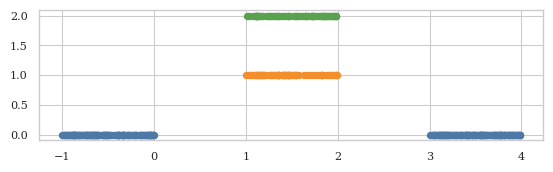

In [4]:
colors = {1: colorblind_codes["blue"], 2: colorblind_codes["orange"], 3: colorblind_codes["green"]}
f, ax = make_full_page_figure(style="ICML")
for cls in [0, 1, 2]:
    mask = (Y == cls)
    ax.scatter(X[mask], Y[mask],
                s=20, color=colors[cls+1])

# 2. Ensemble training

In [5]:
# ============================================================
# 2. MODEL 
# ============================================================

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)


def train_one_model():
    model = Net()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    reg = RegularizerDare(lambda_reg=0.01)
    for epoch in range(200):
        for xb, yb in dl:
            opt.zero_grad()
            out = model(xb)
            loss = F.cross_entropy(out, yb) - min(1.0, epoch / 10) * reg(model)
            # loss = F.cross_entropy(out, yb) 
            loss.backward()
            opt.step()
    return model

class RegularizerDare(nn.Module):
    def __init__(self, lambda_reg=0.01):
        super(RegularizerDare, self).__init__()
        self.lambda_reg = lambda_reg

    def forward(self, model):
        total_loss = 0
        for param in model.parameters():
            total_loss += param.square().log2().sum()
        return total_loss * self.lambda_reg


In [6]:
M = 20
ensemble = [train_one_model() for _ in range(M)]

# 3. EVALUATE UNCERTAINTY ON GRID

In [7]:
# ============================================================
# 3. EVALUATE UNCERTAINTY ON GRID
# ============================================================

grid = np.linspace(x0-2, x3+2, 800)
grid_t = torch.tensor(grid, dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    preds = []
    for model in ensemble:
        p = F.softmax(model(grid_t), dim=1)
        preds.append(p.unsqueeze(0))

    preds = torch.cat(preds, dim=0)          # (M, N, 3)
    mean_p = preds.mean(dim=0)               # (N, 3)

In [8]:
TU = entropy(mean_p, axis=1)
AU = entropy(preds,axis=2).mean(axis=0)   

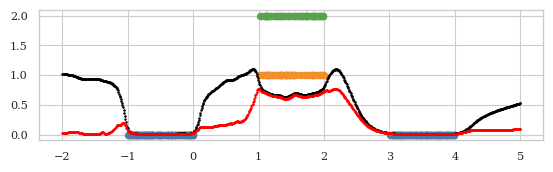

In [9]:
f, ax = make_full_page_figure(style="ICML")
for cls in [0, 1, 2]:
    mask = (Y == cls)
    ax.scatter(X[mask], Y[mask],
                s=20, color=colors[cls+1])
plt.scatter(grid, TU, color='black', s=1, label='Total Uncertainty')
plt.scatter(grid, AU, color='red', s=1, label='Total Uncertainty')


4. BPS vs APS

In [10]:
credals = preds.permute(1, 0, 2).numpy()
b_BPS = solve_b_in_batches(credals, 0.9, batch_size=100)
b_APS = solve_b_in_batches(mean_p.unsqueeze(1).numpy(), 0.9, batch_size=100)

# bb = np.zeros_like(credals)
# for i in range(credals.shape[1]):
#     bb[:,i,:] = solve_b_in_batches(credals[:, i:i+1, :], nominal_coverage=0.9, batch_size=100)
# b_APS_so = np.mean(bb, axis=1)

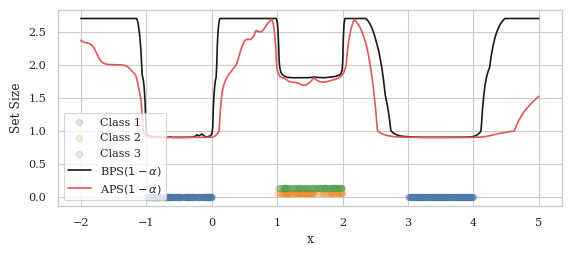

In [25]:
f, ax = make_full_page_figure(style="ICML", relative_figsize=(1, 1.5))
for cls in [0, 1, 2]:
    mask = (Y == cls)
    ax.scatter(X[mask], Y[mask]/15,
                s=20, color=colors[cls+1], alpha=0.2, label=f"Class {cls+1}")
plt.plot(grid, b_BPS.sum(axis=1), color="k", label=r"BPS$(1-\alpha)$")
plt.plot(grid, b_APS.sum(axis=1), color=colorblind_codes["red"], label=r"APS$(1-\alpha)$")
# plt.plot(grid, b_APS_so.sum(axis=1), color='green', label="APS SO")
plt.legend(loc='lower left')
plt.xlabel("x")
plt.ylabel("Set Size")
# plt.grid(False)
os.makedirs(os.path.join(root_path, "all_figures", "toy_example"), exist_ok=True)
plt.savefig(os.path.join(root_path, "all_figures", "toy_example", "ss_comparison.pdf"), format="pdf", bbox_inches='tight', pad_inches=0)